# Compare annotations

Side-by-side view of the presolved model's matrix coloured by two different
partition assignments:
- **Left**: original annotation transferred onto the presolved matrix (surviving variables only)
- **Right**: partition found by running the hypergraph partitioner directly on the presolved model

Change `MODEL_NAME` in the cell below to switch models.

In [1]:
from typing import Tuple

regions:    int             = 13
resolution: int             = 8
range:      Tuple[float, float] = (0.25, 0.5)
cf:         float           = None
is_mip:     bool            = False
has_obj:    bool            = True

MODEL_NAME = (
    f'r{regions}_res{resolution}'
    f'_f{range[0]:.4f}_t{range[1]:.4f}'
    + (f'_cf{cf}' if cf else '')
    + ('_mip' if is_mip  else '')
    + ('_obj' if has_obj else '')
)
MODEL_NAME = 'benchmarks/MIPLIB/irish-electricity'
regions = 269
print(MODEL_NAME)

MAX_MPI_PROCS = 2  # cap MPI processes to avoid OOM


benchmarks/MIPLIB/irish-electricity


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('../..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import MODELS, PAPILO_PRESOLVED_MODELS
from pipstools.io import read_gdx
from src.detection.annotation import read_annotation
from src.detection.visualisation import (
    transfer_partition,
    plot_partition,
    compute_partition_stats,
    render_stats,
    read_integer_col_names,
)

_suffix = ('_mip' if is_mip else '') + ('_obj' if has_obj else '')

ANNOTATIONS_ORIG      = Path(f'/data/energy-system-preprocessing/annotations{_suffix}/original')
ANNOTATIONS_PRESOLVED = Path(f'/data/energy-system-preprocessing/annotations{_suffix}/presolved')
BLOCKS_BASE           = Path('/data/energy-system-preprocessing/blocks')

gdx_orig      = ANNOTATIONS_ORIG      / f'{MODEL_NAME}.gdx'
gdx_presolved = ANNOTATIONS_PRESOLVED / f'{MODEL_NAME}.gdx'
mps_orig      = MODELS                / MODEL_NAME / 'original.mps'
mps_pre       = PAPILO_PRESOLVED_MODELS / MODEL_NAME / 'reduced.mps'

BLOCKS_ORIG = BLOCKS_BASE / MODEL_NAME / 'original'
BLOCKS_PRE  = BLOCKS_BASE / MODEL_NAME / 'reduced'

for p in (gdx_orig, gdx_presolved):
    if not p.exists():
        raise FileNotFoundError(
            f'{p} not found — run experiments/setup/annotate_models.ipynb first'
        )

print(f'Model : {MODEL_NAME}')
print(f'Orig  : {gdx_orig}')
print(f'Pre   : {gdx_presolved}')
print(f'MPS   : {mps_pre}')
print(f'Blocks: {BLOCKS_BASE / MODEL_NAME}')


FileNotFoundError: /data/energy-system-preprocessing/annotations_obj/original/benchmarks/MIPLIB/irish-electricity.gdx not found — run experiments/setup/annotate_models.ipynb first

## Load annotations

In [ ]:
# Original annotation — only need name + partition for the label transfer
cols_orig, rows_orig = read_annotation(gdx_orig)

# Presolved annotation — need the full GDX (A matrix + partitions) for plotting
A_pre, cols_pre, rows_pre, objcoef_pre = read_gdx(gdx_presolved)

# Integer variable names from each MPS (used for green column highlights)
int_cols_orig = read_integer_col_names(mps_orig) if mps_orig.exists() else set()
int_cols_pre  = read_integer_col_names(mps_pre)  if mps_pre.exists()  else set()

print(f'Original  : {len(cols_orig)} vars, {len(rows_orig)} rows  ({len(int_cols_orig)} integer)')
print(f'Presolved : {len(cols_pre)} vars, {len(rows_pre)} rows, {len(A_pre)} nnz  ({len(int_cols_pre)} integer)')

Original  : 39602 vars, 35962 rows  (0 integer)
Presolved : 38395 vars, 34742 rows, 136606 nnz  (0 integer)


## Transfer original partition labels onto the presolved matrix

In [ ]:
cols_orig_on_pre, rows_orig_on_pre = transfer_partition(
    cols_pre, rows_pre,
    cols_orig, rows_orig,
)

# Quick check: partition value counts for both views
import polars as pl
print('Original labels on presolved matrix (col partition counts):')
print(cols_orig_on_pre.group_by('partition').len().sort('partition'))
print()
print('Presolved labels (col partition counts):')
print(cols_pre.group_by('partition').len().sort('partition'))

Original labels on presolved matrix (col partition counts):
shape: (14, 2)
┌───────────┬──────┐
│ partition ┆ len  │
│ ---       ┆ ---  │
│ u32       ┆ u32  │
╞═══════════╪══════╡
│ 1         ┆ 98   │
│ 2         ┆ 2940 │
│ 3         ┆ 2966 │
│ 4         ┆ 2947 │
│ 5         ┆ 2955 │
│ …         ┆ …    │
│ 10        ┆ 2952 │
│ 11        ┆ 2937 │
│ 12        ┆ 2935 │
│ 13        ┆ 2938 │
│ 14        ┆ 2937 │
└───────────┴──────┘

Presolved labels (col partition counts):
shape: (14, 2)
┌───────────┬──────┐
│ partition ┆ len  │
│ ---       ┆ ---  │
│ u32       ┆ u32  │
╞═══════════╪══════╡
│ 1         ┆ 98   │
│ 2         ┆ 2945 │
│ 3         ┆ 2944 │
│ 4         ┆ 2946 │
│ 5         ┆ 2946 │
│ …         ┆ …    │
│ 10        ┆ 2946 │
│ 11        ┆ 2947 │
│ 12        ┆ 2947 │
│ 13        ┆ 2945 │
│ 14        ┆ 2945 │
└───────────┴──────┘


## Side-by-side comparison

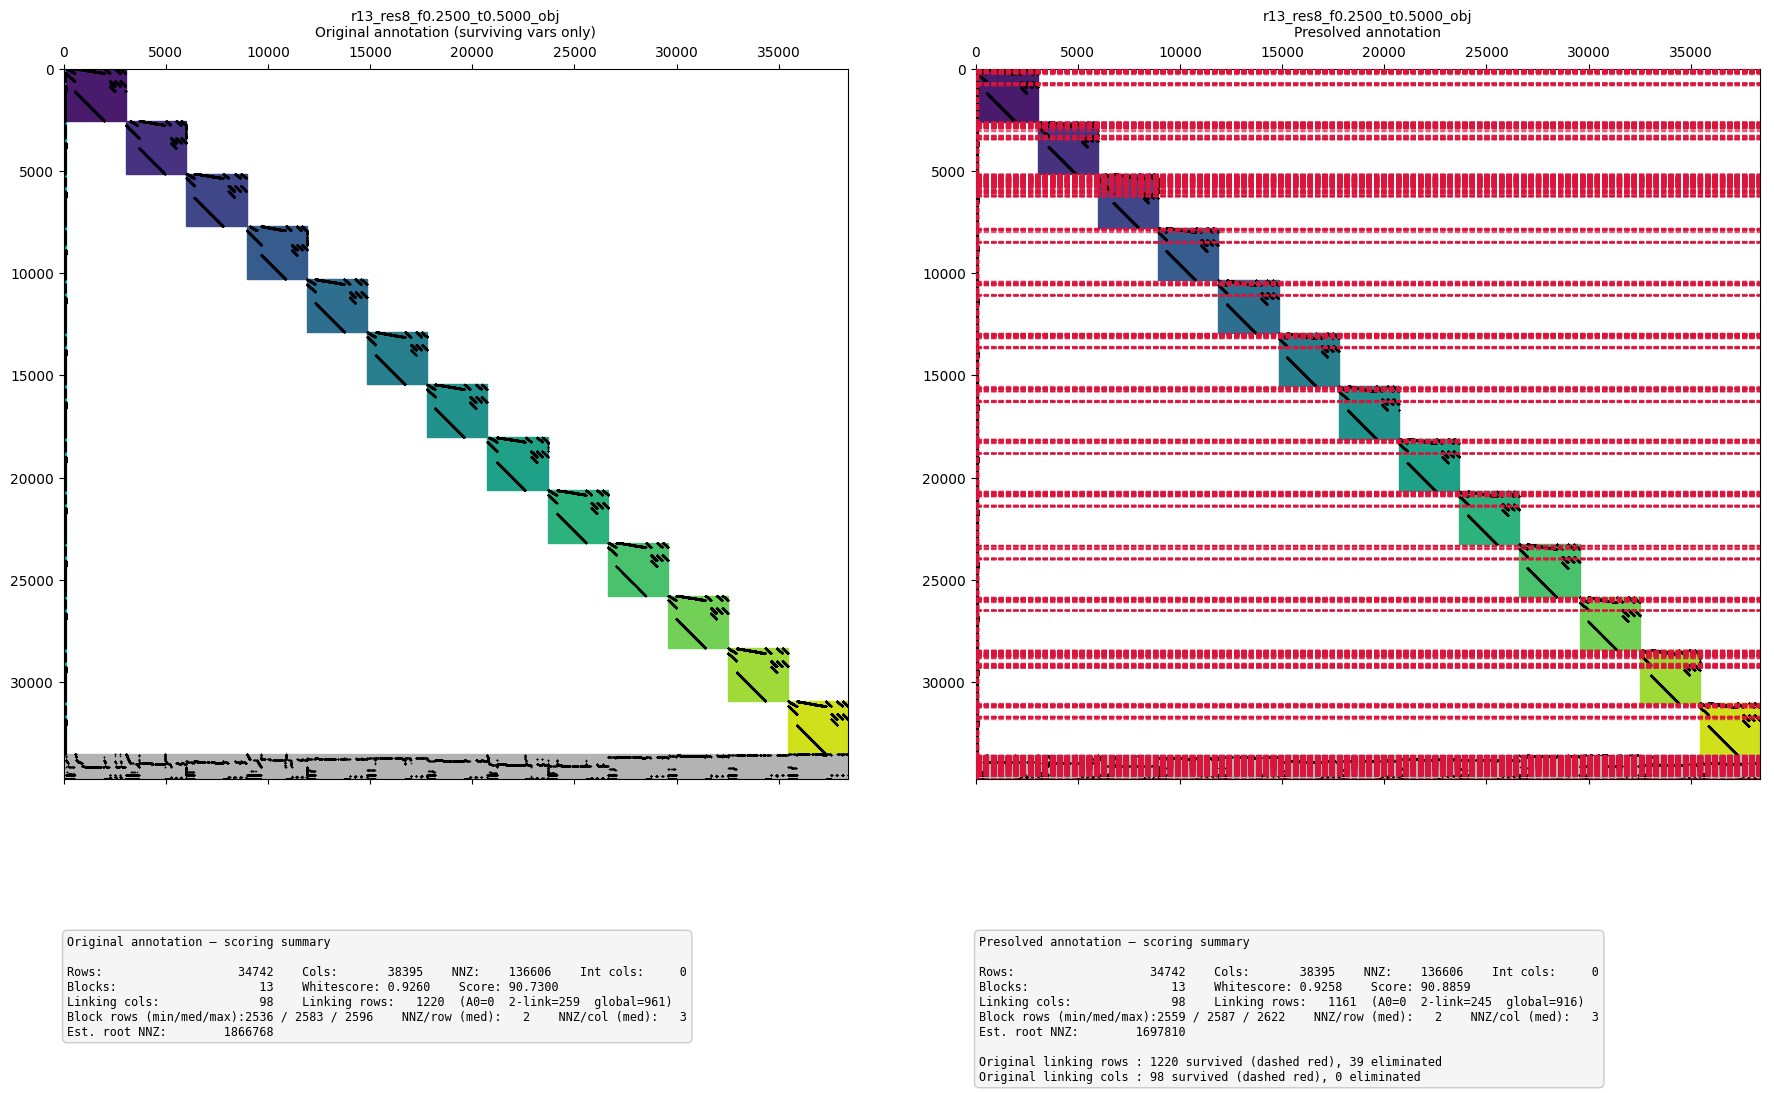

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pipstools.utils import get_blocks_ids

SKIP_BLOCKS = False   # set True for large models to show only first/last 3 blocks
COLORMAP    = 'viridis'

# Identify originally-linking rows and cols in the original annotation
_, orig_link_first, orig_link_last = get_blocks_ids(rows_orig, cols_orig)
orig_linking_row_names = set(
    rows_orig.filter(pl.col("partition").is_in(orig_link_last + orig_link_first))["name"].to_list()
)
orig_linking_col_names = set(
    cols_orig.filter(pl.col("partition").is_in(orig_link_first))["name"].to_list()
)

presolved_row_names = set(rows_pre["name"].to_list())
presolved_col_names = set(cols_pre["name"].to_list())

surviving_linking_rows  = orig_linking_row_names & presolved_row_names
eliminated_linking_rows = orig_linking_row_names - presolved_row_names
surviving_linking_cols  = orig_linking_col_names & presolved_col_names
eliminated_linking_cols = orig_linking_col_names - presolved_col_names

# Integer cols visible in the presolved matrix for each annotation
# Left plot: original integer cols that survived presolve
# Right plot: cols that are integer in the presolved model
int_cols_orig_on_pre = int_cols_orig & presolved_col_names

stats_orig = compute_partition_stats(A_pre, cols_orig_on_pre, rows_orig_on_pre,
                                     integer_col_names=int_cols_orig_on_pre)
stats_pre  = compute_partition_stats(A_pre, cols_pre, rows_pre,
                                     integer_col_names=int_cols_pre)

fig = plt.figure(figsize=(22, 13))
gs  = GridSpec(2, 2, figure=fig, height_ratios=[5, 1], hspace=0.35, wspace=0.15)

ax1      = fig.add_subplot(gs[0, 0])
ax2      = fig.add_subplot(gs[0, 1])
ax_info1 = fig.add_subplot(gs[1, 0])
ax_info2 = fig.add_subplot(gs[1, 1])

plot_partition(
    ax1, A_pre, cols_orig_on_pre, rows_orig_on_pre,
    colormap=COLORMAP, skip_blocks=SKIP_BLOCKS,
    title=f'{MODEL_NAME}\nOriginal annotation (surviving vars only)',
    integer_col_names=int_cols_orig_on_pre,
    highlight_row_names=eliminated_linking_rows,
    highlight_col_names=eliminated_linking_cols,
)
plot_partition(
    ax2, A_pre, cols_pre, rows_pre,
    colormap=COLORMAP, skip_blocks=SKIP_BLOCKS,
    title=f'{MODEL_NAME}\nPresolved annotation',
    highlight_row_names=surviving_linking_rows,
    highlight_col_names=surviving_linking_cols,
    integer_col_names=int_cols_pre,
)

n_elim_r = len(eliminated_linking_rows)
n_surv_r = len(surviving_linking_rows)
n_elim_c = len(eliminated_linking_cols)
n_surv_c = len(surviving_linking_cols)
elim_note = [
    f'Original linking rows : {n_surv_r} survived (dashed red), {n_elim_r} eliminated',
    f'Original linking cols : {n_surv_c} survived (dashed red), {n_elim_c} eliminated',
]

render_stats(ax_info1, stats_orig, title='Original annotation — scoring summary')
render_stats(ax_info2, stats_pre,  title='Presolved annotation — scoring summary',
             extra_lines=elim_note)

plt.show()

## Step 6 — PIPS-IPM++ solve comparison

Split each annotation of the **presolved** MPS into per-block GDX files via
`split_to_blocks`, then solve both with PIPS-IPM++ and compare:
- **Original annotation** (transferred label-for-label onto the presolved matrix)
- **Presolved annotation** (partitioned directly on the reduced model)

Metrics: objective value accuracy (relative difference) and wall-clock solve time.

In [ ]:
import re
import subprocess
import time

import gamspy_base

from src.config import PIPS_PATH
from src.solvers.split import split_to_blocks

PIPS_TIMEOUT = None
GMSPIPS  = PIPS_PATH / 'build' / 'gmspips'
GAMS_DIR = gamspy_base.directory

BLOCKS_ORIG.mkdir(parents=True, exist_ok=True)
BLOCKS_PRE.mkdir(parents=True, exist_ok=True)

# --- Case 1: original annotation transferred onto presolved MPS ---
print('[original] splitting ...')
n_orig = split_to_blocks(mps_pre, BLOCKS_ORIG, annotation_gdx=gdx_orig, transfer=True)
print(f'[original] {n_orig} diagonal blocks')

# --- Case 2: presolved annotation used directly ---
print('[presolved] splitting ...')
n_pre = split_to_blocks(mps_pre, BLOCKS_PRE, annotation_gdx=gdx_presolved)
print(f'[presolved] {n_pre} diagonal blocks')


# --- PIPS runner ---
def _run_pips(block_dir, n_diag, label):
    n_procs = min(n_diag + 1, MAX_MPI_PROCS)
    cmd = [
        'mpirun', '-np', str(n_procs),
        str(GMSPIPS), str(n_diag + 1),
        str(Path(block_dir) / f'block_{n_diag}b'),
        GAMS_DIR,
        'scaleGeo',
    ]
    print(f'\n[{label}] {" ".join(cmd)}')
    t0     = time.perf_counter()
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=PIPS_TIMEOUT)
    wall   = time.perf_counter() - t0
    out    = result.stdout + result.stderr
    m      = re.search(r'---Objective value:\s*([+-]?[0-9]*\.?[0-9]+(?:[eE][+-]?[0-9]+)?)', out)
    return {
        'label':      label,
        'objective':  float(m.group(1)) if m else None,
        'wall_time':  wall,
        'returncode': result.returncode,
        'stdout':     out,
    }


print('\n=== Running PIPS-IPM++ ===')
res_orig = _run_pips(BLOCKS_ORIG, n_orig, 'original annotation')
res_pre  = _run_pips(BLOCKS_PRE,  n_pre,  'presolved annotation')

[original] splitting ...
Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
  transfer_partition: 0/38394 vars unmatched, 0/34741 rows unmatched (partition=0)


 50%|█████     | 7/14 [00:00<00:00, 69.16it/s]

[original] 13 diagonal blocks
[presolved] splitting ...


100%|██████████| 14/14 [00:00<00:00, 78.25it/s]


[presolved] 13 diagonal blocks

=== Running PIPS-IPM++ ===

[original annotation] mpirun -np 2 /homes/vm922/energy-system-preprocessing/src/solvers/PIPS-IPMpp/build/gmspips 14 /data/energy-system-preprocessing/blocks/r13_res8_f0.2500_t0.5000_obj/original/block_13b /homes/vm922/espenv/lib/python3.12/site-packages/gamspy_base scaleGeo

[presolved annotation] mpirun -np 2 /homes/vm922/energy-system-preprocessing/src/solvers/PIPS-IPMpp/build/gmspips 14 /data/energy-system-preprocessing/blocks/r13_res8_f0.2500_t0.5000_obj/reduced/block_13b /homes/vm922/espenv/lib/python3.12/site-packages/gamspy_base scaleGeo


In [ ]:
def _fmt(val, fmt='.6g'):
    return format(val, fmt) if val is not None else 'FAILED'


def _rel_diff(a, b):
    if a is None or b is None:
        return '—'
    ref = max(abs(a), abs(b), 1e-12)
    return f'{abs(a - b) / ref * 100:.4f}%'


results = [res_orig, res_pre]

print(f'  {"Annotation":<26} {"Objective":>16} {"Wall time (s)":>14} {"Exit":>5}')
print(f'  {"-" * 64}')
for r in results:
    print(f'  {r["label"]:<26} {_fmt(r["objective"]):>16} {r["wall_time"]:>14.1f} {r["returncode"]:>5}')

print()
print(f'  Objective difference : {_rel_diff(res_orig["objective"], res_pre["objective"])}')

if res_pre['wall_time'] > 0:
    speedup = res_orig['wall_time'] / res_pre['wall_time']
    print(f'  Wall-time speedup    : {speedup:.2f}×  (presolved annotation vs original)')

# --- raw output for diagnosis when objective parsing fails ---
for r in results:
    if r['objective'] is None:
        print(f'\n--- raw stdout/stderr [{r["label"]}] ---')
        print(r['stdout'][:3000])


  Annotation                        Objective  Wall time (s)  Exit
  ----------------------------------------------------------------
  original annotation                  1520.4           68.3     0
  presolved annotation                 1520.4           61.9     0

  Objective difference : 0.0000%
  Wall-time speedup    : 1.10×  (presolved annotation vs original)
